# Semester Final Project

***🎯 Goal:*** Ask a question and answer it with a statistical investigation of your choosing.

Please make sure that you review [the rubric](https://docs.google.com/document/d/1PXHbL4Nvk_SqhOTZBWf4ZHdwnrugab7S6n3LZnxmxr0/edit?usp=sharing) before starting the project. When you are ready, fill out the sections below.

__________________________

## 🔎 My Question

What is the average displacement of a drunk person in 500 steps?

## 📖 My Study 

- *I will be performing a prospective-style observational study, because I will simulate each drunk man’s walk step-by-step and observe what happens as time progresses.*
- *The population will be simulated drunk walkers, each represented by a random walk on a 2-dimensional grid.
Each walker behaves like a person taking one random step at a time (up, down, left, or right).*
- *I will focus on the drunk man's final displacement from the origin?*
- *I will collect data through simulation.*
    - *I will use a simple random sample, where each simulated walker is generated independently and has the same probability distribution for their steps.*
    - *I will use the pseudo-random number generator, random*
- *One potential source of bias is that the simulation assumes perfect randomness and equal probability in all directions, which may not reflect how an actual intoxicated person walks.
This means the model may be biased toward more symmetric behavior than would occur in real life.*

## 🗂️ My Data

*Collect your data using the cell below. When you are done with your collection, read the data into a dataframe and call `info()` on your dataframe.*

In [30]:
import pandas, seaborn, random, math
import matplotlib.pyplot as plt

In [20]:
def runSim(i):
    pos = [0,0]
    for j in range(500):
        print(f"Step: {i, j}", end="\r", flush=True)
        if random.random() < 0.5: #Move in x direction
            pos[0] += random.choice([-1, 1])
        else:
            pos[1] += random.choice([-1, 1])
    pos.append(math.sqrt(pos[0]**2 + pos[1]**2))
    return pos

In [21]:
data = []
for i in range(1000):
    data.append(runSim(i))

In [22]:
df = pandas.DataFrame(data, columns=["x","y","d"])

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       1000 non-null   int64  
 1   y       1000 non-null   int64  
 2   d       1000 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 23.6 KB


## 📊 My Analysis

*Perform your analysis in the cell below. Please feel free to add more cells if you need them!*

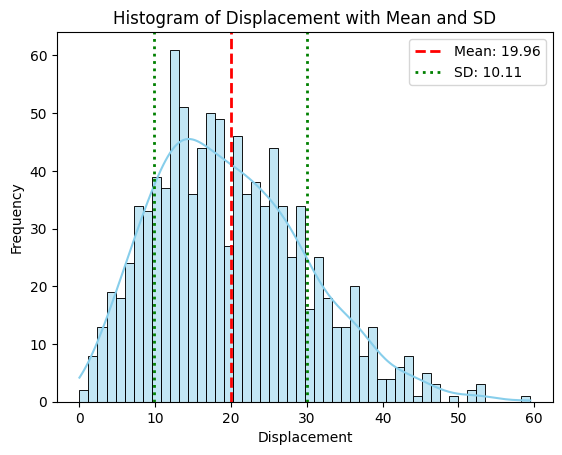

In [41]:
mean_val = df['d'].mean()
std_val = df['d'].std()

# Plot histogram
seaborn.histplot(df['d'], bins=50, kde=True, color='skyblue')

# Add vertical line for mean
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')

# Add vertical lines for ±1 standard deviation
plt.axvline(mean_val + std_val, color='green', linestyle=':', linewidth=2, label=f'SD: {std_val:.2f}')
plt.axvline(mean_val - std_val, color='green', linestyle=':', linewidth=2)

plt.xlabel('Displacement')
plt.ylabel('Frequency')
plt.title('Histogram of Displacement with Mean and SD')
plt.legend()
plt.show()

In [42]:
within_1sd = df[(df['d'] >= mean_val - std_val) & (df['d'] <= mean_val + std_val)].shape[0]

# Count how many values fall within 2 standard deviations
within_2sd = df[(df['d'] >= mean_val - 2*std_val) & (df['d'] <= mean_val + 2*std_val)].shape[0]

# Count how many values fall within 3 standard deviations
within_3sd = df[(df['d'] >= mean_val - 3*std_val) & (df['d'] <= mean_val + 3*std_val)].shape[0]

# Calculate percentages
total = df.shape[0]
print(f"Within 1 SD: {within_1sd/total*100:.2f}%")
print(f"Within 2 SD: {within_2sd/total*100:.2f}%")
print(f"Within 3 SD: {within_3sd/total*100:.2f}%")

Within 1 SD: 69.40%
Within 2 SD: 96.50%
Within 3 SD: 99.40%


## 🧠 My Answer

The average displacement of a drunk man after walking 500 steps from the origin is 19.96 step units. The histogram of the displacements is approximately normal, centered around the mean. With a standard deviation of 10.11, about 69.4% of the data fall within one standard deviation of the mean, which closely aligns with the empirical rule.